In [1]:
!pip install opencv-python
!pip install matplotlib

Upload a low-contrast X-ray image (grayscale):


Saving download.jpg to download.jpg


/tmp/ipykernel_516/1252273934.py:17: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(equalized.ravel(),256,[0,256])


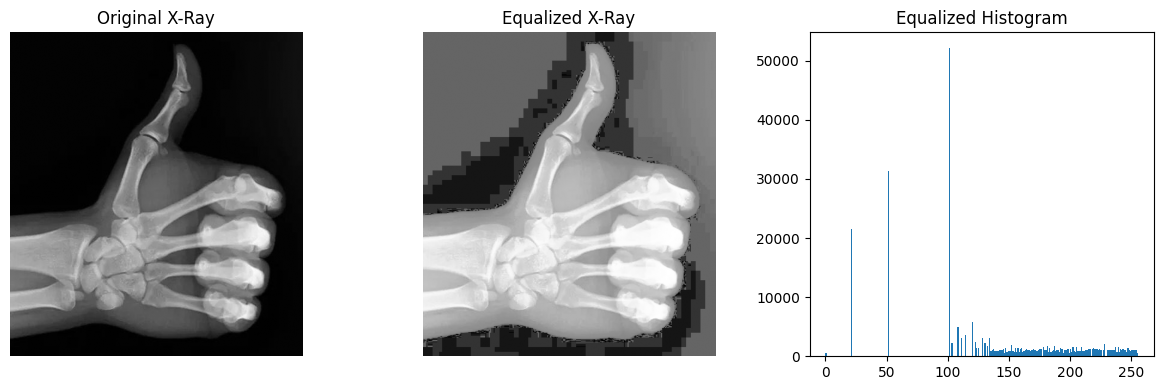

In [2]:
!pip install opencv-python-headless --quiet
import cv2
from google.colab import files
import matplotlib.pyplot as plt
import numpy as np
print("Upload a low-contrast X-ray image (grayscale):")
uploaded = files.upload()
path = list(uploaded.keys())[0]
img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
equalized = cv2.equalizeHist(img)
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(img, cmap='gray'); plt.title("Original X-Ray"); plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(equalized, cmap='gray'); plt.title("Equalized X-Ray"); plt.axis('off')
plt.subplot(1,3,3)
plt.hist(equalized.ravel(),256,[0,256])
plt.title("Equalized Histogram")
plt.tight_layout()
plt.show()

**Question 2**

Upload a low-contrast satellite image:


Saving Explorer-14 Space Satellite Painted Stock Vector - Illustration of painted, apollo_ 164416366.jpg to Explorer-14 Space Satellite Painted Stock Vector - Illustration of painted, apollo_ 164416366.jpg


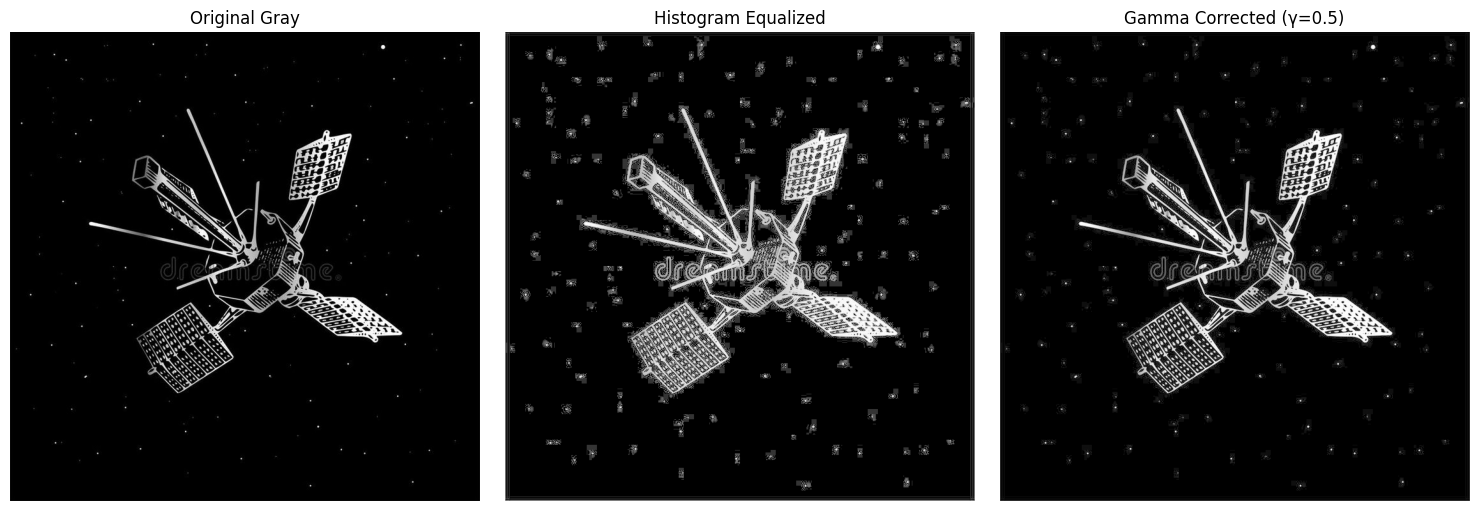

In [3]:
!pip install opencv-python-headless --quiet
import cv2
import numpy as np
from google.colab import files
import matplotlib.pyplot as plt
print("Upload a low-contrast satellite image:")
uploaded = files.upload()
path = list(uploaded.keys())[0]
img = cv2.imread(path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
equalized = cv2.equalizeHist(gray)
gamma = 0.5 # brighten
gamma_corr = np.array(255 * (gray/255) ** gamma, dtype='uint8')
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(gray, cmap='gray'); plt.title("Original Gray"); plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(equalized, cmap='gray'); plt.title("Histogram Equalized"); plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(gamma_corr, cmap='gray'); plt.title(f"Gamma Corrected (γ={gamma})"); plt.axis('off')
plt.tight_layout()
plt.show()

**Question 3**

Upload a low-light surveillance frame:


Saving ☕ THE GUY WHO DIDN'T LIKE MUSICALS (2018).jpg to ☕ THE GUY WHO DIDN'T LIKE MUSICALS (2018).jpg


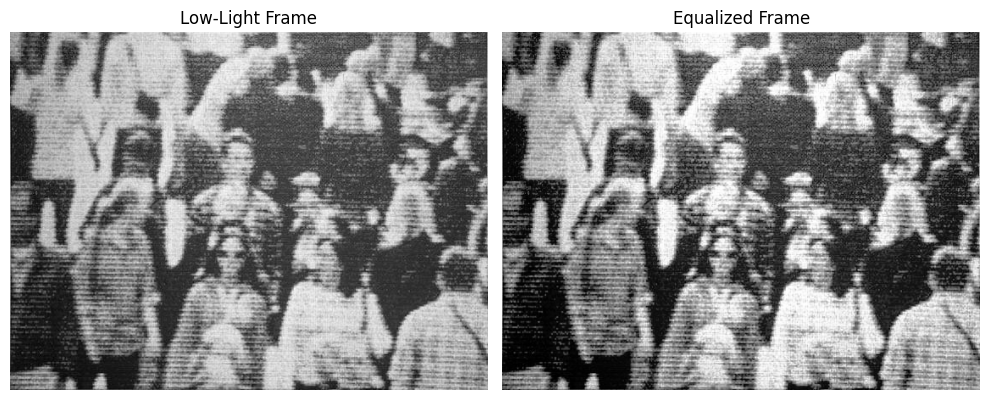

In [4]:
!pip install opencv-python-headless --quiet
import cv2
import numpy as np
from google.colab import files
import matplotlib.pyplot as plt
print("Upload a low-light surveillance frame:")
uploaded = files.upload()
path = list(uploaded.keys())[0]
img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
equalized = cv2.equalizeHist(img)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(img, cmap='gray'); plt.title("Low-Light Frame"); plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(equalized, cmap='gray'); plt.title("Equalized Frame"); plt.axis('off')
plt.tight_layout()
plt.show()

**Question 4**

Upload a scanned document image (grayscale or color):


Saving 1958 3 24 Rapport d'examen medical d'Elvis.jpg to 1958 3 24 Rapport d'examen medical d'Elvis.jpg


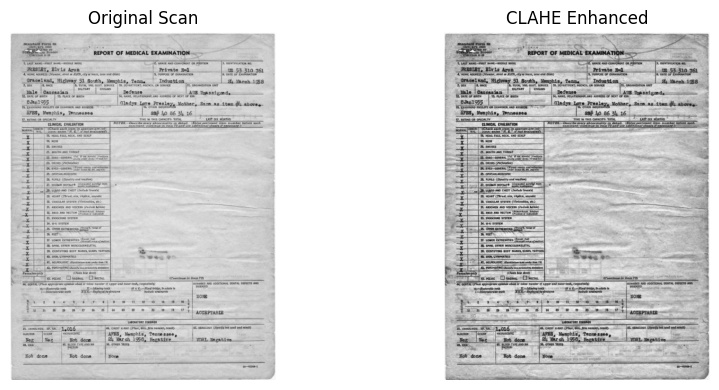

In [5]:
!pip install opencv-python-headless --quiet
import cv2
import numpy as np
from google.colab import files
import matplotlib.pyplot as plt
print("Upload a scanned document image (grayscale or color):")
uploaded = files.upload()
path = list(uploaded.keys())[0]
img = cv2.imread(path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# Apply CLAHE (Contrast Limited Adaptive Histogram Equalization)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
enhanced = clahe.apply(gray)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(gray, cmap='gray'); plt.title("Original Scan"); plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(enhanced, cmap='gray'); plt.title("CLAHE Enhanced"); plt.axis('off')
plt.tight_layout()
plt.show()

**Question 5**

Upload a foggy road image:


Saving The Road of Fog.jpg to The Road of Fog.jpg


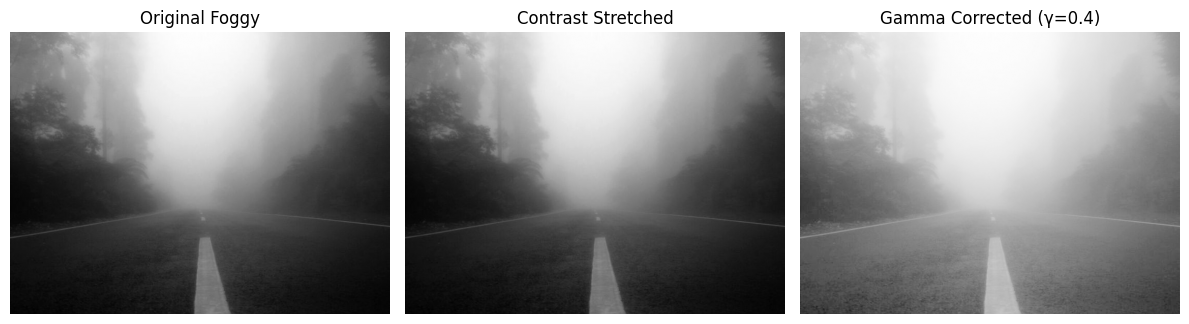

In [6]:
!pip install opencv-python-headless --quiet
import cv2
import numpy as np
from google.colab import files
import matplotlib.pyplot as plt
print("Upload a foggy road image:")
uploaded = files.upload()
path = list(uploaded.keys())[0]
img = cv2.imread(path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# Contrast Stretching (min-max normalization)
min_val = np.min(gray)
max_val = np.max(gray)
stretched = ((gray - min_val) / (max_val - min_val) * 255).astype('uint8')
# Gamma Correction to brighten (gamma < 1)
gamma = 0.4
gamma_corrected = np.array(255 * (stretched / 255) ** gamma, dtype='uint8')
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(gray, cmap='gray'); plt.title("Original Foggy"); plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(stretched, cmap='gray'); plt.title("Contrast Stretched"); plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(gamma_corrected, cmap='gray'); plt.title(f"Gamma Corrected (γ={gamma})");
plt.axis('off')
plt.tight_layout()
plt.show()

**Question 6**

Upload an underwater image:


Saving underwater.jpg to underwater.jpg


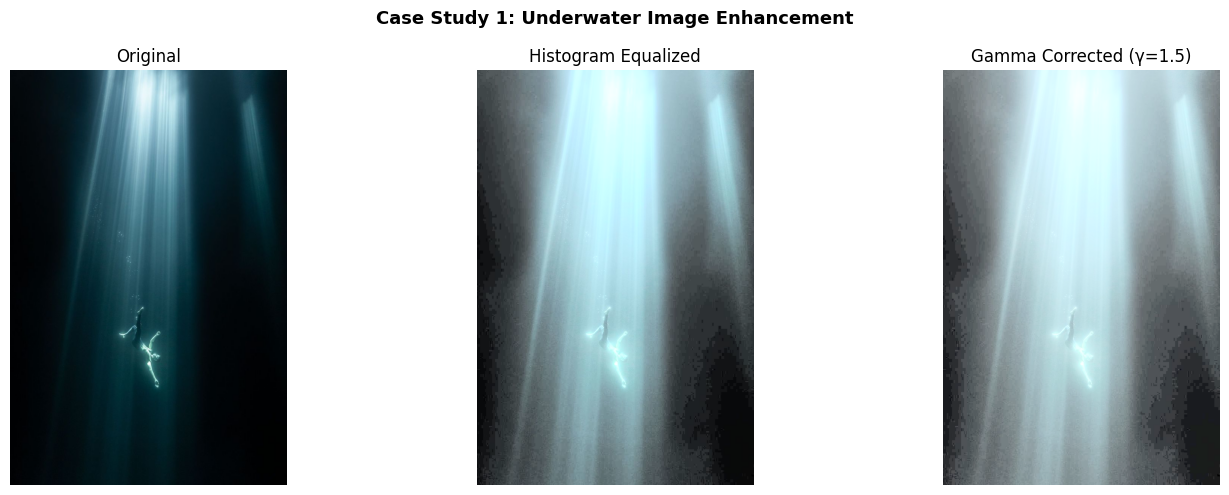

Saved: underwater_enhanced.jpg


In [7]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("Upload an underwater image:")
uploaded = files.upload()
input_path = list(uploaded.keys())[0]

def enhance_underwater(input_path, gamma=1.5, output_path="underwater_enhanced.jpg"):
    image = cv2.imread(input_path)
    img_yuv = cv2.cvtColor(image, cv2.COLOR_BGR2YUV)

    # Histogram Equalization on Y (brightness) channel
    img_yuv[:, :, 0] = cv2.equalizeHist(img_yuv[:, :, 0])
    equalized = cv2.cvtColor(img_yuv, cv2.COLOR_YUV2BGR)

    # Gamma Correction to brighten the image
    inv_gamma = 1.0 / gamma
    table = np.array([(i / 255.0) ** inv_gamma * 255 for i in range(256)]).astype("uint8")
    corrected = cv2.LUT(equalized, table)

    cv2.imwrite(output_path, corrected)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    titles = ["Original", "Histogram Equalized", f"Gamma Corrected (γ={gamma})"]
    imgs = [image, equalized, corrected]
    for ax, img, title in zip(axes, imgs, titles):
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(title); ax.axis("off")
    plt.suptitle("Case Study 1: Underwater Image Enhancement", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()
    print(f"Saved: {output_path}")

enhance_underwater(input_path)

**Question 7**

Upload a nighttime road image:


Saving nighttime road.jpg to nighttime road.jpg


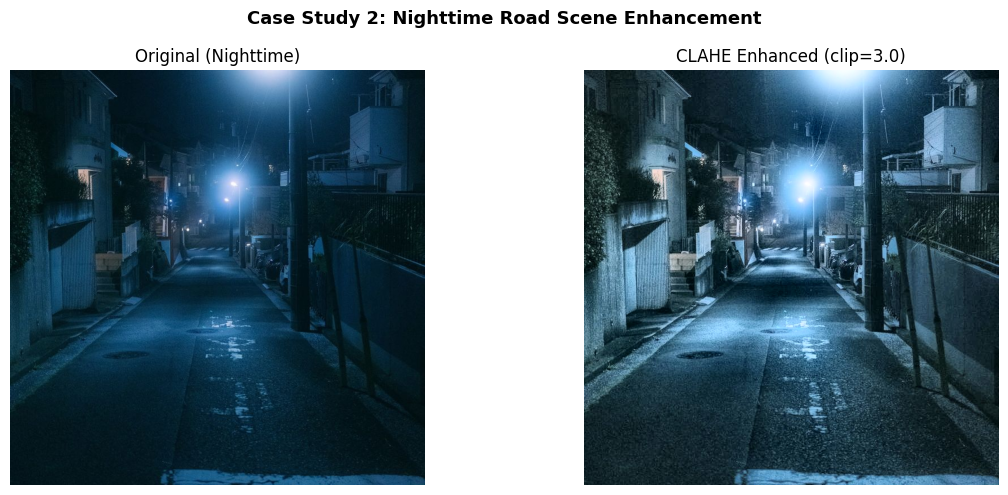

Saved: night_enhanced.jpg


In [8]:
from google.colab import files
import cv2
import matplotlib.pyplot as plt

print("Upload a nighttime road image:")
uploaded = files.upload()
input_path = list(uploaded.keys())[0]

def enhance_nighttime(input_path, clip_limit=3.0, tile_size=(8, 8), output_path="night_enhanced.jpg"):
    image = cv2.imread(input_path)
    img_yuv = cv2.cvtColor(image, cv2.COLOR_BGR2YUV)

    # CLAHE on Y (luminance) channel — enhances local contrast without amplifying noise
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_size)
    img_yuv[:, :, 0] = clahe.apply(img_yuv[:, :, 0])
    enhanced = cv2.cvtColor(img_yuv, cv2.COLOR_YUV2BGR)

    cv2.imwrite(output_path, enhanced)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB));    axes[0].set_title("Original (Nighttime)"); axes[0].axis("off")
    axes[1].imshow(cv2.cvtColor(enhanced, cv2.COLOR_BGR2RGB)); axes[1].set_title(f"CLAHE Enhanced (clip={clip_limit})"); axes[1].axis("off")
    plt.suptitle("Case Study 2: Nighttime Road Scene Enhancement", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()
    print(f"Saved: {output_path}")

enhance_nighttime(input_path)

**Question 8**

Upload a dark security camera frame:


Saving security frame.jpg to security frame.jpg


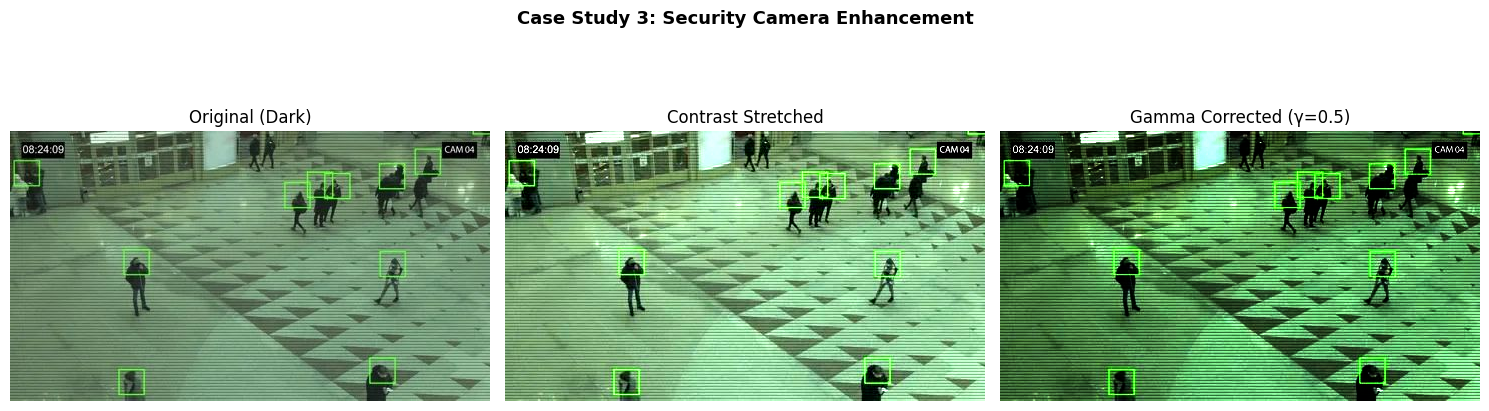

Saved: security_enhanced.jpg


In [9]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("Upload a dark security camera frame:")
uploaded = files.upload()
input_path = list(uploaded.keys())[0]

def enhance_security_frame(input_path, gamma=0.5, output_path="security_enhanced.jpg"):
    image = cv2.imread(input_path)

    # Contrast Stretching — maps pixel range to full 0–255
    min_val = np.percentile(image, 2)
    max_val = np.percentile(image, 98)
    stretched = np.clip((image - min_val) / (max_val - min_val) * 255, 0, 255).astype("uint8")

    # Gamma Correction — brightens dark areas (gamma < 1 = brighter)
    inv_gamma = 1.0 / gamma
    table = np.array([(i / 255.0) ** inv_gamma * 255 for i in range(256)]).astype("uint8")
    corrected = cv2.LUT(stretched, table)

    cv2.imwrite(output_path, corrected)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    titles = ["Original (Dark)", "Contrast Stretched", f"Gamma Corrected (γ={gamma})"]
    imgs = [image, stretched, corrected]
    for ax, img, title in zip(axes, imgs, titles):
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(title); ax.axis("off")
    plt.suptitle("Case Study 3: Security Camera Enhancement", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()
    print(f"Saved: {output_path}")

enhance_security_frame(input_path)

**Question 9**

Upload a foggy or hazy traffic image:


Saving foggy road.jpg to foggy road.jpg


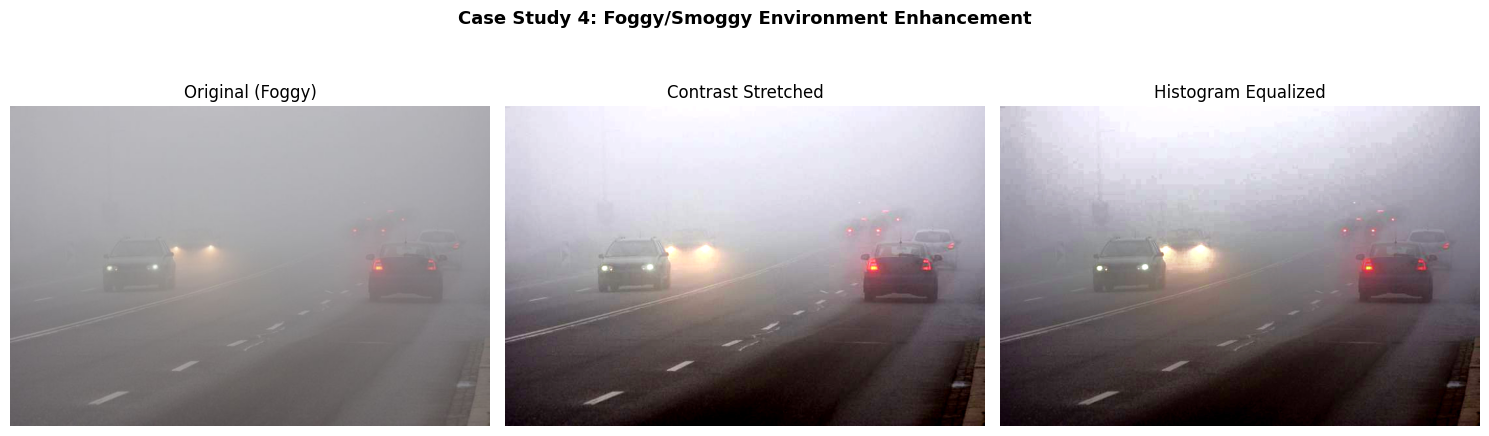

Saved: defog_enhanced.jpg


In [10]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("Upload a foggy or hazy traffic image:")
uploaded = files.upload()
input_path = list(uploaded.keys())[0]

def enhance_foggy_image(input_path, output_path="defog_enhanced.jpg"):
    image = cv2.imread(input_path)

    # Contrast Stretching — pulls out washed-out detail in foggy scenes
    min_val = np.percentile(image, 2)
    max_val = np.percentile(image, 98)
    stretched = np.clip((image - min_val) / (max_val - min_val) * 255, 0, 255).astype("uint8")

    # Histogram Equalization on Y channel to improve overall contrast
    img_yuv = cv2.cvtColor(stretched, cv2.COLOR_BGR2YUV)
    img_yuv[:, :, 0] = cv2.equalizeHist(img_yuv[:, :, 0])
    equalized = cv2.cvtColor(img_yuv, cv2.COLOR_YUV2BGR)

    cv2.imwrite(output_path, equalized)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    titles = ["Original (Foggy)", "Contrast Stretched", "Histogram Equalized"]
    imgs = [image, stretched, equalized]
    for ax, img, title in zip(axes, imgs, titles):
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(title); ax.axis("off")
    plt.suptitle("Case Study 4: Foggy/Smoggy Environment Enhancement", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()
    print(f"Saved: {output_path}")

enhance_foggy_image(input_path)

**Question 10**

Upload a satellite thermal image:


Saving download.jpg to download (1).jpg


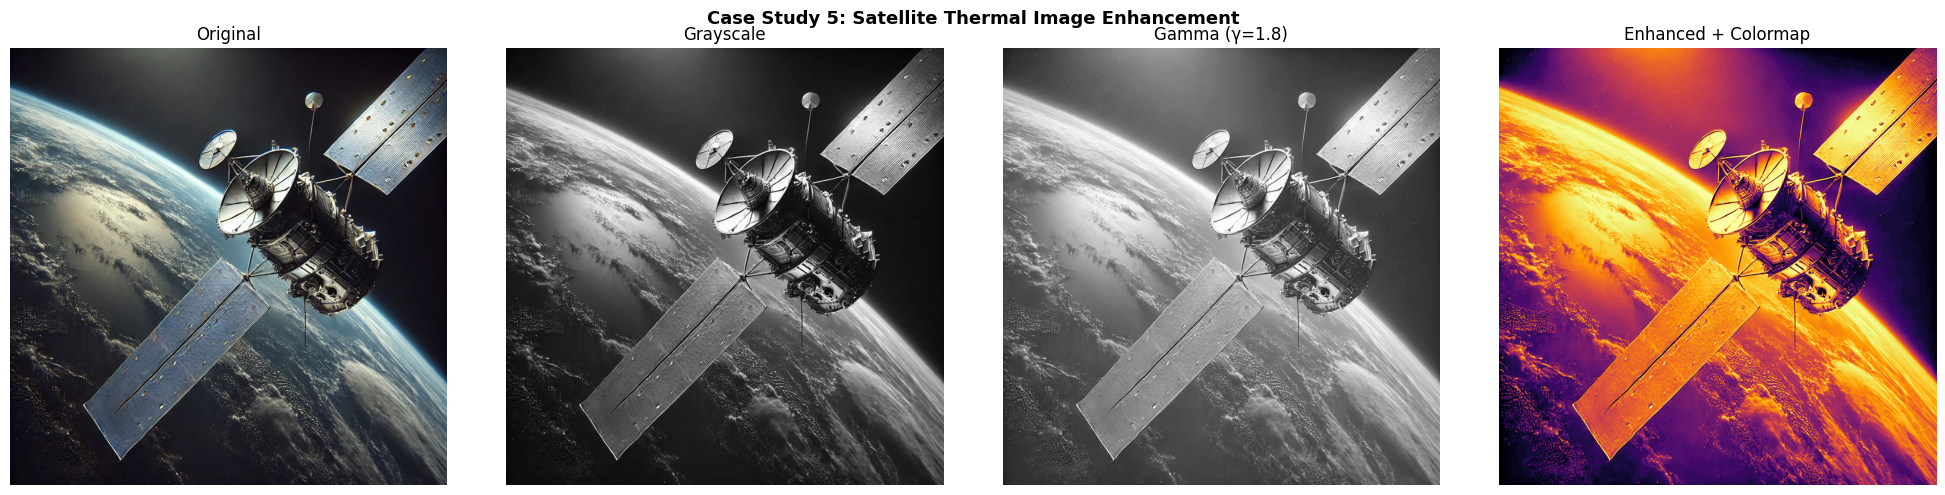

Saved: thermal_enhanced.jpg


In [11]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("Upload a satellite thermal image:")
uploaded = files.upload()
input_path = list(uploaded.keys())[0]

def enhance_thermal_image(input_path, gamma=1.8, output_path="thermal_enhanced.jpg"):
    image = cv2.imread(input_path)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Gamma Correction — boosts dim temperature gradients
    inv_gamma = 1.0 / gamma
    table = np.array([(i / 255.0) ** inv_gamma * 255 for i in range(256)]).astype("uint8")
    gamma_corrected = cv2.LUT(gray, table)

    # Histogram Equalization — spreads thermal intensity across full range
    equalized = cv2.equalizeHist(gamma_corrected)

    # Apply colormap for better thermal visualization
    thermal_colored = cv2.applyColorMap(equalized, cv2.COLORMAP_INFERNO)

    cv2.imwrite(output_path, thermal_colored)

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    titles = ["Original", "Grayscale", f"Gamma (γ={gamma})", "Enhanced + Colormap"]
    imgs_display = [
        cv2.cvtColor(image, cv2.COLOR_BGR2RGB),
        gray,
        gamma_corrected,
        cv2.cvtColor(thermal_colored, cv2.COLOR_BGR2RGB)
    ]
    cmaps = [None, "gray", "gray", None]
    for ax, img, title, cmap in zip(axes, imgs_display, titles, cmaps):
        ax.imshow(img, cmap=cmap)
        ax.set_title(title); ax.axis("off")
    plt.suptitle("Case Study 5: Satellite Thermal Image Enhancement", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()
    print(f"Saved: {output_path}")

enhance_thermal_image(input_path)